In [1]:
#Imports the pandas, matplotlib, and numpy library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Reads in a student performance spreadsheet as a dataframe to look at data
df = pd.read_csv('student_performance_dataset.csv')

In [3]:
df

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [4]:
#Analysis questions in regards to the data
'''
Does sleeping and studying impact male and female students final grades?
Do male or female students study more on average?
How many hours of studying does a student with a poor Final Grade average?
How many hours should a student study to get a high Final Grade?
'''

'\nWhat is the average amount of study time for overall students?\nDo males are females study more on average?\nWhat is the final grade based on a certain amount of study time?\nHow much sleep do these students get?\n'

In [5]:
#Dropping the parental_education column as I feel this does not impact any of my analysis questions
df2 = df.drop(columns=['parental_education'])

In [6]:
#Prints a newly created dataframe to check if there are any Null values
print(df2.isnull().sum())

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64


In [7]:
#Checks datatypes, to ensure there is no need to make any changes based off the data to be filtered
print(df2.dtypes)

student_id                      int64
gender                         object
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
internet_access                object
extracurricular_activities     object
part_time_job                  object
previous_grade                float64
final_exam_score              float64
final_grade                    object
dtype: object


In [8]:
#Exports the created dataframe into a csv file
df2.to_csv('student_perf.csv', index=False)

In [9]:
#Reads through an excel spreadsheet for the pivot table on Sheet 2
#This pivot table data will be used for the graphing/comparison
df_sleep = pd.read_excel("student_perf2.xlsx", sheet_name="Sheet2")

In [10]:
df_sleep

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,Row Labels,Count of student_id,Average of sleep_hours,Average of study_time_hours2
2,Female,510,6.808235,3.562157
3,A,140,6.980714,4.575
4,B,186,6.858065,3.587634
5,C,134,6.719403,2.887313
6,D,44,6.411364,2.538636
7,F,6,6.133333,1.716667
8,Male,490,6.790408,3.579592
9,A,144,7.053472,4.713889


In [11]:
#Drops the First row with Null values
df_sleep2 = df_sleep.drop(index=0)

In [12]:
df_sleep2

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
1,Row Labels,Count of student_id,Average of sleep_hours,Average of study_time_hours2
2,Female,510,6.808235,3.562157
3,A,140,6.980714,4.575
4,B,186,6.858065,3.587634
5,C,134,6.719403,2.887313
6,D,44,6.411364,2.538636
7,F,6,6.133333,1.716667
8,Male,490,6.790408,3.579592
9,A,144,7.053472,4.713889
10,B,168,6.744643,3.59881


In [13]:
#Sets 2 x_axis and a width for the grouped bar charts
x_axis = np.arange(5)
x_axis2 = np.arange(5)
width = .15

In [14]:
#Separates the data. Female data will follow this dataframe and rows for it's on graph
df_female = df_sleep2.iloc[1:7]

In [15]:
df_female.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3'], dtype='object')

In [16]:
#Renames the Columns on the dataframe
df_female2 = df_female.rename(columns={'Unnamed: 0': 'Female_Grade', 'Unnamed: 1': 'Total_Students', 'Unnamed: 2': "Average_sleep", 'Unnamed: 3': "Average_studytime"})

In [17]:
df_female2

,Female_Grade,Total_Students,Average_sleep,Average_studytime
2,Female,510,6.808235,3.562157
3,A,140,6.980714,4.575
4,B,186,6.858065,3.587634
5,C,134,6.719403,2.887313
6,D,44,6.411364,2.538636
7,F,6,6.133333,1.716667


In [18]:
#Drop the Female Row
df_female3 = df_female2.iloc[1:]

In [19]:
#Drop the Total Students Column 
df_female4 = df_female3.drop(columns='Total_Students')

In [20]:
#Final data frame to be used for the grouped bar chart
df_female4

,Female_Grade,Average_sleep,Average_studytime
3,A,6.980714,4.575
4,B,6.858065,3.587634
5,C,6.719403,2.887313
6,D,6.411364,2.538636
7,F,6.133333,1.716667


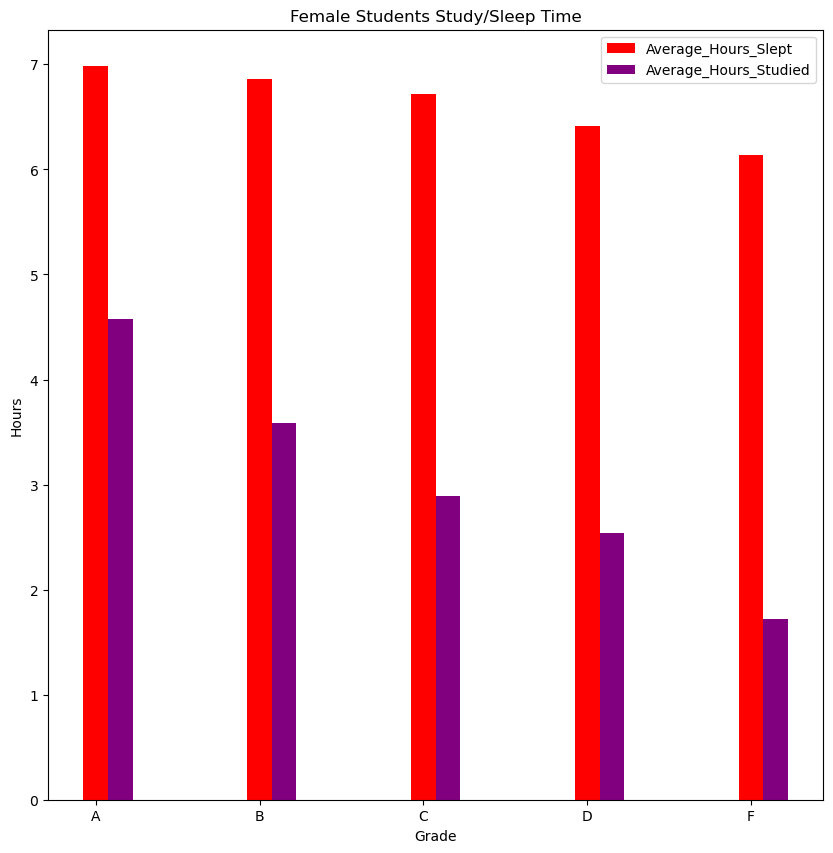

In [21]:
#Creates a grouped bar chart with the female dataframe/dataset
#Compares Female Students Average sleep, Average studytime per Grade
plt.figure(figsize=(10,10))

plt.bar(x_axis, df_female4.iloc[:, 1], width = width, color ='red')
plt.bar(x_axis+width, df_female4.iloc[:, 2], width = width, color ='purple')

plt.xticks(x_axis, ['A', 'B', 'C', 'D', 'F'])
plt.xlabel("Grade")
plt.ylabel("Hours")
plt.title('Female Students Study/Sleep Time')

plt.legend(["Average_Hours_Slept", "Average_Hours_Studied"])
plt.show()

In [22]:
#Separates the data. Male data will follow this dataframe and rows for it's on graph
df_male = df_sleep2.iloc[7:13]

In [23]:
#Renames the Columns on the dataframe
df_male2 = df_male.rename(columns={'Unnamed: 0': 'Male_Grade', 'Unnamed: 1': 'Total_Students', 'Unnamed: 2': "Average_sleep", 'Unnamed: 3': "Average_studytime"})

In [24]:
df_male2

,Male_Grade,Total_Students,Average_sleep,Average_studytime
8,Male,490,6.790408,3.579592
9,A,144,7.053472,4.713889
10,B,168,6.744643,3.59881
11,C,127,6.66063,2.866142
12,D,45,6.486667,2.071111
13,F,6,6.783333,2.233333


In [25]:
#Drop the Total Students Column 
df_male3 = df_male2.drop(columns='Total_Students')

In [28]:
#Final data frame to be used for the grouped bar chart
df_male4 = df_male3.iloc[1:]

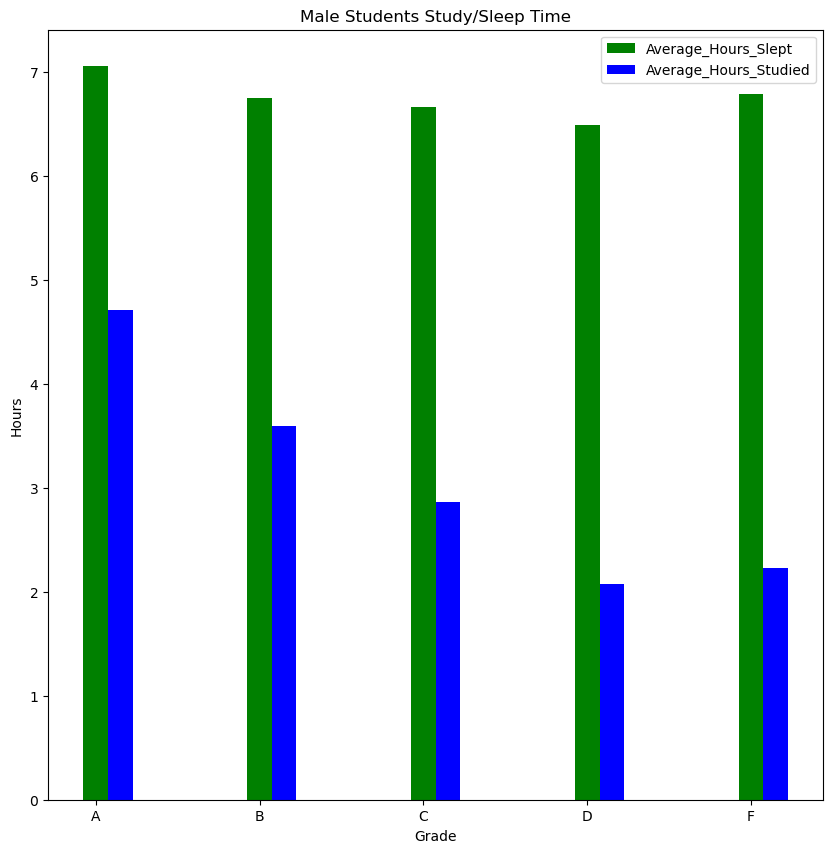

In [29]:
#Creates a grouped bar chart with the male dataframe/dataset
#Compares Male Students Average sleep, Average studytime per Grade
plt.figure(figsize=(10,10))

plt.bar(x_axis2, df_male4.iloc[:, 1], width = width, color ='green')
plt.bar(x_axis2+width, df_male4.iloc[:, 2], width = width, color ='blue')

plt.xticks(x_axis2, ['A', 'B', 'C', 'D', 'F'])
plt.xlabel("Grade")
plt.ylabel("Hours")
plt.title('Male Students Study/Sleep Time')

plt.legend(["Average_Hours_Slept", "Average_Hours_Studied"])
plt.show()

In [30]:
#Summary / Analysis on the data
'''
The graphs show the correlation between both Male and Female students and on average how much hours of sleep and studying
affect their grade. Overall, it appears the trend of data shows that the more both Males and Females sleep and study they will get a higher grade,
and the less they study they will get a lower grade.

Female students show the greatest amount of performance with their final grade when getting more sleep. Noticeably the less a female student slept,
the less they studied. This equates to lower grades. Students who slept near 7 hours and studied for almost 5 hours on average received an A.
If these female students were to sleep near the same amount of 7 hours and studied less than 5 hours, on average they are not expected to make an A
as the final grade.

Male students show similar performance between average amount of sleep and hours studied to their final grade, with one slight difference.
Male students that received an A were sleeping on average 7 hours and studying for atleast 5 hours. This indicates that Male students on average
will need to sleep more than females to receive the Final Grade of an A. Another noticeable differences comes with male students that receive a F.
These students sleep alot more than students that received a B, C, and D in the class. This is the exact opposite with female students where the females
that receive an F, are those that sleep the least.

In Conclusion, there is a heavy correlation between both female and male students sleeping and studying to get better grades. The less a student studies,
the worse they tend to perform. However, there is an outlier with Male students sleeping for an extended period of time and getting the worst grade. 
The average student will need to study a significant amount to get better grades.
'''

'''
Within the results I failed to determine what type of students are in this dataset. This would be a great factor to help narrow which type of students
they are based off the data. I would like to gather this information next time I look at student data. I believe High School, Undergrad and Grad students
all may showcase different results.
'''

'\nThe graphs show the correlation between both Male and Female students and on average how much hours of sleep and studying\naffect their grade. Overall, it appears the trend of data shows that the more both Males and Females sleep and study they will get a higher grade,\nand the less they study they will get a lower grade.\n\nFemale students show the greatest amount of performance with their final grade when getting more sleep. Noticeably the less a female student slept,\nthe less they studied. This equates to lower grades. Students who slept near 7 hours and studied for almost 5 hours on average received an A.\nIf these female students were to sleep near the same amount of 7 hours and studied less than 5 hours, on average they are not expected to make an A\nas the final grade.\n\nMale students show similar performance between average amount of sleep and hours studied to their final grade, with one slight difference.\nMale students that received an A were sleeping on average 7 hours 